Step 1 — Prepare the Regional Sales Data

In [16]:
import pandas as pd

df = pd.read_csv("Superstore.csv")

print(df.shape)
print(df.columns.tolist())

(9994, 19)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [13]:
df[["Order Date", "Region", "Sales"]].head()

,Order Date,Region,Sales
0,11-08-2016,South,261.9600
1,11-08-2016,South,731.9400
2,06-12-2016,West,14.6200
3,10-11-2015,South,957.5775
4,10-11-2015,South,22.3680


In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Year"] = df["Order Date"].dt.year

In [19]:
print("Years:", sorted(df["Year"].unique()))
print("Regions:", df["Region"].unique())

Years: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Regions: ['South' 'West' 'Central' 'East']


Step 2 — Calculate Annual Sales by Region

In [20]:
regional_sales = (
    df.groupby(["Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

regional_sales

,Year,Region,Sales
0,2014,Central,103838.1646
1,2014,East,128680.4570
2,2014,South,103845.8435
3,2014,West,147883.0330
4,2015,Central,102874.2220
5,2015,East,156332.0570
6,2015,South,71359.9805
7,2015,West,139966.2495
8,2016,Central,147429.3760
9,2016,East,180685.8220


In [21]:
regional_sales["Sales"] = regional_sales["Sales"].round(2)

regional_sales

,Year,Region,Sales
0,2014,Central,103838.16
1,2014,East,128680.46
2,2014,South,103845.84
3,2014,West,147883.03
4,2015,Central,102874.22
5,2015,East,156332.06
6,2015,South,71359.98
7,2015,West,139966.25
8,2016,Central,147429.38
9,2016,East,180685.82


In [22]:
print("Rows:", len(regional_sales))

Rows: 16


Step 3 — Calculate Year-over-Year Growth

Sort the data

In [23]:
regional_sales = regional_sales.sort_values(
    ["Region", "Year"]
).reset_index(drop=True)

In [24]:
regional_sales["Previous Year Sales"] = (
    regional_sales.groupby("Region")["Sales"].shift(1)
)

Calculate Growth %

In [25]:
regional_sales["Growth %"] = (
    (regional_sales["Sales"] - regional_sales["Previous Year Sales"])
    / regional_sales["Previous Year Sales"]
    * 100
)

In [26]:
regional_sales["Growth %"] = regional_sales["Growth %"].round(2)

In [27]:
regional_sales

,Year,Region,Sales,Previous Year Sales,Growth %
0,2014,Central,103838.16,NaN,NaN
1,2015,Central,102874.22,103838.16,-0.93
2,2016,Central,147429.38,102874.22,43.31
3,2017,Central,147098.13,147429.38,-0.22
4,2014,East,128680.46,NaN,NaN
5,2015,East,156332.06,128680.46,21.49
6,2016,East,180685.82,156332.06,15.58
7,2017,East,213082.90,180685.82,17.93
8,2014,South,103845.84,NaN,NaN
9,2015,South,71359.98,103845.84,-31.28


Step 4 — Create the Regional Growth Chart

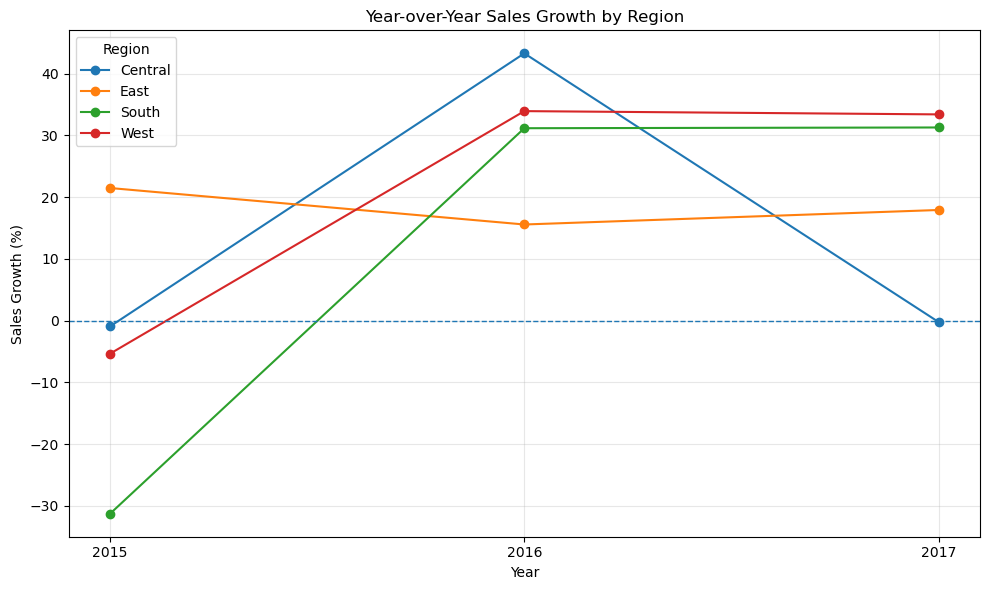

In [28]:
import matplotlib.pyplot as plt

growth_data = regional_sales.dropna(subset=["Growth %"])

plt.figure(figsize=(10, 6))

for region in growth_data["Region"].unique():
    region_data = growth_data[growth_data["Region"] == region]

    plt.plot(
        region_data["Year"],
        region_data["Growth %"],
        marker="o",
        label=region
    )

plt.axhline(y=0, linestyle="--", linewidth=1)

plt.title("Year-over-Year Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Sales Growth (%)")
plt.xticks(sorted(growth_data["Year"].unique()))
plt.legend(title="Region")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Step 5 — Create the Final Growth Table

In [29]:
growth_table = regional_sales[
    ["Year", "Region", "Sales", "Previous Year Sales", "Growth %"]
].copy()

growth_table

,Year,Region,Sales,Previous Year Sales,Growth %
0,2014,Central,103838.16,NaN,NaN
1,2015,Central,102874.22,103838.16,-0.93
2,2016,Central,147429.38,102874.22,43.31
3,2017,Central,147098.13,147429.38,-0.22
4,2014,East,128680.46,NaN,NaN
5,2015,East,156332.06,128680.46,21.49
6,2016,East,180685.82,156332.06,15.58
7,2017,East,213082.90,180685.82,17.93
8,2014,South,103845.84,NaN,NaN
9,2015,South,71359.98,103845.84,-31.28


In [30]:
growth_table["Sales"] = growth_table["Sales"].round(2)
growth_table["Previous Year Sales"] = growth_table["Previous Year Sales"].round(2)
growth_table["Growth %"] = growth_table["Growth %"].round(2)

growth_table

,Year,Region,Sales,Previous Year Sales,Growth %
0,2014,Central,103838.16,NaN,NaN
1,2015,Central,102874.22,103838.16,-0.93
2,2016,Central,147429.38,102874.22,43.31
3,2017,Central,147098.13,147429.38,-0.22
4,2014,East,128680.46,NaN,NaN
5,2015,East,156332.06,128680.46,21.49
6,2016,East,180685.82,156332.06,15.58
7,2017,East,213082.90,180685.82,17.93
8,2014,South,103845.84,NaN,NaN
9,2015,South,71359.98,103845.84,-31.28


In [31]:
growth_summary = (
    regional_sales
    .dropna(subset=["Growth %"])
    .groupby("Region")["Growth %"]
    .agg(["mean", "min", "max"])
    .round(2)
    .reset_index()
)

growth_summary

,Region,mean,min,max
0,Central,14.05,-0.93,43.31
1,East,18.33,15.58,21.49
2,South,10.40,-31.28,31.30
3,West,20.67,-5.35,33.95


Step 6 — Identify the 5 Business Insights

the highest growth

In [32]:
highest_growth = (
    growth_table
    .dropna(subset=["Growth %"])
    .loc[
        growth_table.dropna(subset=["Growth %"])["Growth %"].idxmax()
    ]
)

highest_growth

Year                        2016
Region                   Central
Sales                  147429.38
Previous Year Sales    102874.22
Growth %                   43.31
Name: 2, dtype: object

the lowest growth

In [33]:
lowest_growth = (
    growth_table
    .dropna(subset=["Growth %"])
    .loc[
        growth_table.dropna(subset=["Growth %"])["Growth %"].idxmin()
    ]
)

lowest_growth

Year                        2015
Region                     South
Sales                   71359.98
Previous Year Sales    103845.84
Growth %                  -31.28
Name: 9, dtype: object

The highest sales year-region combination


In [34]:
highest_sales = growth_table.loc[
    growth_table["Sales"].idxmax()
]

highest_sales

Year                        2017
Region                      West
Sales                  250128.37
Previous Year Sales    187480.18
Growth %                   33.42
Name: 15, dtype: object

average growth by region

In [35]:
growth_summary.sort_values(
    "mean",
    ascending=False
)

,Region,mean,min,max
3,West,20.67,-5.35,33.95
1,East,18.33,15.58,21.49
0,Central,14.05,-0.93,43.31
2,South,10.40,-31.28,31.30


total sales by region

In [36]:
regional_total_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

regional_total_sales

Region
West       725457.82
East       678781.24
Central    501239.89
South      391721.90
Name: Sales, dtype: float64

Final Business Insights
1. West showed the highest average regional growth.
West recorded an average growth of 20.67%, with growth ranging from -5.35% to 33.95% across the analyzed periods.

2. East showed relatively consistent growth.
East had an average growth of 18.33%, with a narrower range of 15.58% to 21.49%, indicating relatively stable year-over-year performance.

3. Central experienced the highest single-year growth.
Central recorded its highest growth of 43.31% in 2016, when sales increased from 102,874.22 to 147,429.38.

4. South had the most volatile growth.
South had the lowest observed growth, -31.28% in 2015, while its maximum growth reached 31.30%. This indicates substantial variation in year-over-year performance.

5. West generated the highest overall sales.

Total sales by region were:
Region	Total Sales
West	725,457.82
East	678,781.24
Central	501,239.89
South	391,721.90


West therefore combined the highest overall sales with a high average growth rate, while South requires closer investigation because of its larger growth fluctuations.

Business Recommendations

- Examine factors contributing to West's sustained growth and sales performance.
- Investigate the causes of South's large year-to-year fluctuations.
- Maintain East's relatively consistent growth pattern.
- Investigate the factors behind Central's strong 2016 growth.
- Monitor both sales volume and growth rate when evaluating regional performance.